# 10장 : 암과 싸워 이기기 위한 파이토치 활용

 + 원본 데이터 파일을 읽어 처리하기
 + 데이터를 표현하는 파이썬 클래스 구현
 + 데이터를 파이토치에서 사용 가능한 포맷으로 변환
 + 훈련 데이터와 검증 데이터의 시각화

지금까지 2부의 개괄적인 목표를 알아봤으며, 우리가 만들 시스템에서 데이터가 어떻게 흘러들어갈지에 대한 윤곽도 잡았다. 이제부터는 원본 데이터를 읽어들이고 전처리하는 루틴을 만들어야 한다. 앞으로 다룰 여러 중요한 프로젝트에서 수행할 작업은 이와 같은 전처리 루틴과 유사할 것이다.

우리의 목표는 원본 CT 스캔 데이터와 데이터에 달아놓은 애노테이션 목록으로 훈련 샘플을 만드는 것이다. 간단해 보이지만 필요한 데이터를 읽어서 추출하려면 꽤 많은 사전 작업이 필요하다. 이 작업은 꽤 중요한 단계로, 앞서 4장에서 이러한 데이터 변환 방식에 대해 설명한 바 있다.

## 10.1 원본 CT 데이터 파일

CT 데이터는 메타데이터 헤더 정보가 포함된 .mhd 파일과 3차원 배열을 만들 원본 데이터 바이트를 포함하는 .raw 파일로, 종류는 총 두 가지다. 각 파일 이름은 $\textbf{시리즈 UID}$ $(\text{DICOM}^{\text{Digital Imaging and Communications in Medicine}} \text{명명법에서 유래했다})$ 라고 불리는 CT 스캔 단일 식별자로 시작한다. 예를 들어 시리즈 UID 1.2.3 의 경우, 1.2.3.mhd 와 1.2.3.raw의 두 가지 파일이 있다.

`CT` 클래스는 mhd와 raw파일을 읽어서 3차원 배열을 만들고 환자 좌표계를 배열에서 필요로 하는 인덱스, 행, 열 좌표 (코드상에서는 `_irc`로 끝나는 변수에 해당)로 바꿔주는 변환 행렬도 만든다. 

LUNA에서 제공하는 애노테이션 데이터도 읽어야 한다. 애노테이션 데이터에는 각 결절의 좌표목록, 악성 여부, 그리고 해당 CT 스캔의 시리즈 UID가 포함되어 있다. 결절 좌표가 좌표계 변환을 거치면 결절의 중심에 해당하는 복셀의 인덱스, 행, 열 정보가 생긴다.

`(I, R, C)` 좌표를 사용하면 CT 데이터의 작은 3차원 부분 단면을 얻어 모델에 대한 입력으로 사용할 수 있다. 이 3차원 배열과 함께, 우리는 훈련 샘플 튜플의 나머지를 구성해야 한다. 여기에는 샘플 배열, 결절의 상태 플래그, 시리즈 UID를 비롯해, 결절 후보군의 CT 리스트 중 이 샘플이 몇 번째 인덱스인지 등이 포함된다. 파이토치가 `Dataset` 서브클래스를 통해 얻고자 하는 것이 정확히 이 튜플이다. 동시에 이 튜플은 원본 데이터를 표준 구조의 파이토치 텐서로 변환하는 과정의 마지막 부분이다.

데이터를 제한하거나 잘라서 모델에 노이즈가 끼지 않게 하는 것은 매우 중요하다. 또한 지나치게 걸러내어 중요 시그널을 날려버리지 않게 해야 한다. 특히, 정규화 이후 데이터의 범위가 적절한지도 확인해야 한다. 데이터에서 $\text{이상값}^{\text{outlier}}$ 를 제거하는 것은 특별히 데이터에 극단적인 이상값이 많은 경우에 유용하다. 경우에 따라서 입력 변환을 위해 직접 고안한 알고리즘을 사용하기도 하는데 이를 $\textbf{피처 엔지니어링}^{\text{feature engineering}}$ 이라고 부른다. 2부에서는 사용하지 않을 예정이다.

## 10.2 LUNA 애노테이션 데이터 파싱

`candidates.csv`에는 조직 덩어리가 결절일 가능성이 있는지와 악성 종양 또는 양성 종양 여부, 그리고 그 밖의 정보가 들어 있다. 우리는 이 데이터를 전체 후보 리스트를 만드는 데 사용하여 추후에 훈련 데이터셋과 검증 데이터셋으로 나눌 것이다.

  - `candidates.csv`는 원래 ISBI 2016/LUNA16 워크숍에서 쓰던 후보 위치 집합
  - `candidates_V2.csv`는 false positive reduction track용으로 확장된 후보 위치 집합

  - `(Get-Content candidates.csv).Count` : 윈도우 운영체제에서 파일의 행 개수 카운트하는 bash 명령어
  - `(Get-Content .\candidates.csv | Select-String ',1$').Count` : 윈도우 운영체제에서 결절이라서 1로 끝나는 행 개수 카운트

전체 행 개수는 551,066이며 각각은 `series_uid`와 `(X,Y,Z)` 좌표, 그리고 결절 상태를 의미하는 `class`열 (0은 혈관처럼 결절이 아닌 경우, 1은 결절로서 악성이거나 양성)로 구성된다. 실제 결절로 분류된 1,351개의 케이스가 있다.

`annotations.csv`파일에는 결절로 플래그된 후보들에 대한 정보가 포함되어 있다. 특별히 `diameter_mm`정보를 주목할 만하다.

대략 1,200개 결절에 대한 크기 정보가 있다. 이 유용한 정보를 결절 크기의 분포로 가정하여 훈련 데이터와 검증 데이터를 만드는 데 유용하게 사용할 수 있다. 이와 같은 정보가 없다면 검증셋이 큰 결절 샘플만 가지도록 만들어져 모델의 성능이 떨어지는 것처럼 보일 수도 있다.

### 10.2.1 훈련셋과 검증셋

모든 표준 지도 학습(supervised learning) 작업(예 : 분류 작업)은 데이터를 훈련셋(training set)과 검증셋(validation set)으로 나눈다. 여기서 훈련셋과 검증셋은 모두 실세계 데이터를 반영해야 하며, 일반적인 방식으로 다루는 것을 가정한다.

일단 크기 순으로 데이터를 정렬한 후 매 $N$번째에 대해 검증셋을 넣어서 분포를 반영한 검증셋을 구성하자. 안타깝게도 `annotations.csv`에서 제공하는 위치 정보는 `candidates.csv`의 좌표와 정확하게 일치하지는 않는다.

  - `gc annotations.csv | sls 100225287222365663678666836860`
  - `gc candidates.csv | sls '100225287222365663678666836860.*,1$'`

각 파일에서 일치하는 좌표를 잘라내면 (-128.70, -175.32, -298.39)와 (-128.94, -175.04, -297.87)을 얻는다. 이 결절은 직경 5밀리미터이며 두 포인트는 정확하게 결절의 중심부를 나타내지만 두 좌표가 완벽하게 일치하진 않는다. 따라서 이와 같이 데이터가 불일치한 경우라면, 다룰 가치가 없는 것으로 판단하고 무시하는 것이 맞다. 실제 데이터는 이런 식으로 불완전할 때가 많으므로, 잘 정돈하려면 발품을 팔아야 한다. 이는 나중에 서로 다른 출처로부터 데이터를 가져와 합쳐야 할 때 필요한 전형적인 작업의 한 예다.

### 10.2.2 애노테이션 데이터와 후보 데이터 합치기

이제 원본 데이터 파일이 어떻게 생겼는지 확인했으니 이 둘을 합치는 `getCandidateInfoList` 함수를 만들어보자. 각 결절 정보를 담아둘 $\text{네임드 튜플}^{\text{named tuple}}$ 을 파일 상단에 두고 사용하자.

In [1]:
from collections import namedtuple

CandidateInfoTuple = namedtuple(
    'CandidateInfoTuple',
    'isNodule_bool, diameter_mm, series_uid, center_xyz')

이 튜플은 우리가 필요로 하는 CT 데이터가 빠져 있으니 훈련 샘플은 아니다. 이 데이터는 우리가 사용하는 전문가의 애노테이션 데이터에 대해 나름대로 깔끔하게 다음어진 통합 인터페이스를 나타낸다. 이런 식으로 모델 훈련 작업과 지저분한 데이터를 처리하는 작업을 분리하는 일은 매우 중요하다. 그렇지 않으면 훈련 루프가 금세 지저분해진다. 예외 케이스 처리를 집어넣는 등 훈련에 집중해야 할 코드가 다른 것들로 채워지기 때문이다.

따라서 프로젝트에서는 지저분한 데이터를 처리하는 영역을 깔끔하게 분리하자. 필요하다면 주저없이 데이터를 가공해서 다시 저장하자.

후보 정보 리스트는 (분류를 위한 모델 훈련에 사용할) 결절의 상태와 (훈련에 사용할 좋은 분포를 얻기 위해 사용할) 결절의 직경(큰 결절이나 작은 결절은 서로 다른 특성을 가질 수 있으니), 그리고 (올바른 CT 스캔에 배치하기 위한) 순번과 (큰 CT에서 후보를 찾기 위한) 중심점을 갖는다.

`NoduleInfoTuple` 인스턴스 리스트를 만드는 함수는 인메모리 캐싱 데코레이터(in-memory caching decorator)를 사용하고 디스크 파일 경로를 얻는다.

일부 데이터 파일은 파싱에 시간이 걸리므로 함수 호출 결과를 메모리에 캐시한다. 인메모리나 온디스크 캐싱을 적절하게 사용하면 데이터 파이프라인 속도가 빨라지게 되고 훈련 속도의 상당한 개선으로 이어질 수 있다.

`requireOnDisk_bool` 파라미터는 사용시에 디스크상에서 시리즈 UID가 발견되는 LUNA 데이터만 사용하고 이에 해당하는 엔트리만 CSV 파일에서 걸러 사용하는 역할을 한다. 또한 훈련 루프 단계에서 데이터의 일부만 실행할 수 있게 되면, 로깅이나 지표, 모델의 체크포인트 등 코드가 의도 대로 동작하는지 쉽게 검증할 수 있다.

후보 정보를 얻었다면 `annotations.csv`의 직경 정보를 합쳐본다. 먼저 애노테이션 정보는 `series_uid`로 그룹화해서 두 파일에서 일치하는 행을 찾아내는 키로 사용한다. 그리고 난뒤 `candidates.csv`의 정보를 사용해서 전체 후보 리스트를 만든다.

주어진 `series_uid`에 해당하는 후보 엔트리에 대해 앞에서 모은 애노테이션 데이터를 루프 돌면서 같은 `series_uid`를 찾고 두 센터 좌표가 동일한 결절로 간주할 만큼 가까운 거리에 있는지를 확인한다. 일치하는 경우를 찾았다면 결절에 대한 직경 정보를 매칭한 셈이다. 일치하지 않는다면 결절의 직경이 0.0 인것으로 간주한다. 우리는 훈련셋과 검증셋에 대해 좋은 결절 크기 분포를 가지도록 필터링할 것이므로 이렇게 부정확한 직경값을 가져도 된다. 하지만 나중에 잘못되었을 경우를 대비해 이런 작업을 해두었다는 사실을 기억하자.

결절의 직경을 합치기 위해 작성해야 할 소소한 코드가 꽤 된다. 안타깝게도 이런 식으로 데이터를 처리하고 다소 적절하게 매칭하는 일은 원본 데이터에 따라 의존적이긴 하지만 매우 흔하다.

데이터를 정렬하면 일부 CT 단면들을 모아 결절 직경에 대해 잘 분포된 실제 결절을 반영하는 덩어리를 얻어올 수 있게 된다.

In [2]:
import functools, glob, os, csv

@functools.lru_cache(1)
def getCandidateInfoList(requireOnDisk_bool = True): # requireOnDisk_bool은 디스크에 없는 데이터 걸러내는 용도
    BASE_DIR = os.getcwd()
    pattern = os.path.join(BASE_DIR, "luna", "subset*", "*.mhd")
    mhd_list = glob.glob(pattern)
    presentOnDisk_set = {os.path.split(p)[-1][:-4] for p in mhd_list}
    # print(presentOnDisk_set)
    # presentOnDisk_list = list(presentOnDisk_set)
    # print(len(presentOnDisk_list))
    diameter_dict: dict[str, list[tuple[tuple[float, float, float], float]]] = {}
    with open(os.path.join(BASE_DIR, "luna", 'annotations.csv'), "r") as f:
        for row in list(csv.reader(f))[1:]:
            series_uid = row[0]
            annotationCenter_xyz = tuple([float(x) for x in row[1:4]])
            annotationDiameter_mm = float(row[4])
            
            # diameter_dict.setdefault(series_uid, []).append(
            #     (annotationCenter_xyz, annotationDiameter_mm)
            # )
            if series_uid not in diameter_dict:
                diameter_dict[series_uid] = []
            diameter_dict[series_uid].append(
                (annotationCenter_xyz, annotationDiameter_mm)
            )
            
    candidateInfo_list = []
    with open(os.path.join(BASE_DIR, "luna", "candidates.csv"), 'r') as f:
        for row in list(csv.reader(f))[1:]:
            series_uid = row[0]
            
            # series_uid가 없으면 서브셋에 있지만(candidates.csv) 디스크에는 없으므로 건너뛴다
            if series_uid not in presentOnDisk_set and requireOnDisk_bool:
                continue
            
            isNodule_bool = bool(int(row[4])) 
            candidateCenter_xyz = tuple([float(x) for x in row[1:4]])
            
            candidateDiameter_mm = 0.0
            for annotation_tup in diameter_dict.get(series_uid, []):
                annotationCenter_xyz, annotationDiameter_mm = annotation_tup
                for i in range(3):
                    delta_mm = abs(candidateCenter_xyz[i] - annotationCenter_xyz[i])
                    # 반경을 얻기 위해 직경을 2로 나누고, 두 개의 결절 센터가 결절의 크기 기준으로
                    # 너무 떨어져 있는지를 반지름의 절반 길이를 기준으로 판정한다(실거리가 아닌 바운딩 박스 체크)
                    if delta_mm > annotationDiameter_mm / 4:
                        break
                else:
                    candidateDiameter_mm = annotationDiameter_mm
                    break
            candidateInfo_list.append(CandidateInfoTuple(isNodule_bool, candidateDiameter_mm, series_uid, candidateCenter_xyz))
    
    # 모든 결절 샘플을 내림차순으로 정렬, 그 뒤에는 (크기 정보가 없는) 결절이 아닌 샘플이 이어져 있는 데이터가 준비되어있다.        
    candidateInfo_list.sort(reverse = True)
    return candidateInfo_list

## 10.3 개별 CT 스캔 로딩

다음은 디스크에서 CT 데이터를 얻어와 파이썬 객체로 변환해서 3차원 결절 밀도 데이터로 사용할 수 있도록 만드는 작업이다. 이 과정은 `.mhd`와 `.raw` 파일로부터 `Ct` 객체에 연결된 경로에 해당한다. 결절 애노테이션 정보는 원본 데이터에서 얻어내고자 하는 영역에 대한 맵(map)이라고 생각하면 된다. 이 맵을 활용하여 관심있는 부분을 추출하려면 먼저, 데이터를 주소로 접근 가능하게 해야 한다.

`CT` 스캔 파일의 원래 포맷은 DICOM이라고 부른다. DICOM 표준의 최초 버전은 1984년에 만들어졌고 그 시절에 만들어진 컴퓨팅 관련 내용들은 다소 깔끔하지 않다(이더넷이 주류가 되기 전인 그 시절 지금은 버려진 전체 섹션이 데이터 링크 계층 프로토콜로 사용되었다).

$\textbf{NOTE}$
> 그동안 우리는 이런 류의 원본 데이터 파일을 파싱하기 위해 전용 라이브러리를 찾느라 발품을 팔았지만, 한번도 들어본 적 없는 포맷이라면 직접 파서를 찾아봐야 한다. 그렇게 기존의 파서를 찾아보는데 들이는 시간이, 난해한 데이터 포맷 파서를 직접 작성하는데 걸리는 시간보다 적기 때문이다. 파이썬 생태계는 하늘 아래 모든 파일 포맷에 대한 파서를 가지고 있으니 항상 기존의 파서를 찾는 습관을 들이자.

다행히도 LUNA는 우리가 이 장에서 사용하려는 데이터를 MetaIO포맷으로 변환해 놓았고 사용하기도 쉽다. 예전에 들어보지 못한 포맷이라도 걱정할 필요가 없다! 데이터 파일 포맷을 블랙박스로 간주하고 친숙한 넘파이 배열로 읽어들이기 위해 `SimpleITK`를 사용할 것이다.

실제 프로젝트라면 아마도 원본 데이터에 어떤 정보 타입이 포함되는지 이해하고 싶겠지만 지금은 디스크의 바이너리 파싱을 위해 `SimpleITK` 서드파티에 의존해도 괜찮다. 입력 데이터에 대한 모든 상세 내용을 파악하는 것과, 데이터 로딩 라이브러리가 넘겨주는 결과의 세부 내용을 모른 채 사용하는 것 사이에서 균형을 유지하는 데에는 어느 정도 경험이 필요하다. 우리는 '비트'가 아닌 '데이터'에 관심이 있으며 정보가 표현되는 방식보다는 정보 자체에 관심이 있는 상황이니까.

주어진 데이터 샘플을 식별 가능하면 편리하다. 예를 들어 어떤 샘플이 문제를 일으키는지 명확하게 잡아 논의할 수도 있고, 분류가 안 되는 샘플만 잡아서 이슈를 디버깅하여 품질을 획기적으로 끌어올릴 수도 있다. 샘플 특성에 따라, 식별자가 숫자나 문자열 같은 단일 값일 수도 있고, 튜플처럼 복잡한 형태를 가질 수도 있다.

특정 CT 스캔을 식별하기 위해 현재 우리는 CT가 만들어질 때 부여된 $\textbf{시리즈 인스턴스 UID}$(`series_uid`)를 사용 중이다. DICOM은 개별 DICOM 파일, 여러 파일 그룹, 처리 과정 등에 단일 식별자(UID)를 주로 사용하고 있다. 여기에서는 UID를 여러 CT 스캔을 참조 시 사용할, ASCII 문자열로 만든 단일 키로 취급한다. 공식적으로 DICOM UID의 유효한 문자는 0에서 9 사이의 숫자와 점 뿐이지만 경우에 따라 UID 를 16진수로 바꾸거나 스펙에 없는 값으로 바꾸기도 한다.

앞서 설명한 10개 서브셋에는 각각 90개의 CT 스캔이 있으며 (전체는 888개), 각 CT 스캔은 `.mhd`와 `.raw` 확장자를 가지는 두 개의 파일로 나뉜다. 여러 파일로 나뉜 데이터의 세부는 `sitk` 루틴에 가려져 있는데 지금 고민할 필요는 없다.

`ct_a`는 3차원 배열이다. 세 개의 차원은 공간을 나타내고 하나는 밀도를 나타낸다. 4장에서 봤듯이 파이토치 텐서에서 채널 정보는 네 번째 차원으로 표현되며 크기는 1이다(흑백이라 1인듯).

### 10.3.1 하운스필드 단위 (매우 중요 : 도메인 지식에 기반한 전처리방법)

다시 언급하지만 우리는 데이터가 저장되는 '비트'보다는 '데이터'자체를 이해해야 한다. 지금이 그러한 점을 이해하기 좋은 시점이다. 데이터의 값과 범위에 대한 미묘한 차이를 이해하지 못하면, 우리는 원하는 학습 방식을 저해하는 값을 모델에 주입하게 될 수도 있다.

이어서, `__init__` 메소드 작성 시에는 `ct_a` 값을 지워줄 필요가 있다. CT 스캔 복셀은 조금은 생소한 $\text{하운스필드 단위}^{\text{Hounsfield Unit, HU}}$로 표시하는데, 일례로 공기는 -1,000HU (1평방센티미터당 거의 0g/cc 에 가깝다)이고 물은 0HU(1g/cc)이며 뼈는 +1,000HU(2~3g/cc)이다.

$\textbf{NOTE}$
> HU 값은 통상적으로 부호화된 12비트 정수로 디스크에 저장하며(16비트 정수 공간을 사용한다)CT 스캐너가 제공하는 정밀도 레벨에는 이 정도가 적당하다. 흥미로울 수는 있지만 프로젝트에 적절한 형식은 아니다.

어떤 CT 스캐너는 스캔 영역을 벗어난 복셀을 나타내기 위해 밀도에 음의 값을 사용한다. 우리의 경우 환자의 몸 외부는 모두 공기이므로 시야에 해당하는 영역을 위해 값이 -1,000HU 이하일 때는 버린다. 비슷하게 뼈나 금속 이식물에 해당하는 밀도값도 필요 없으므로 생물학적으로 정확하지는 않지만 2g/cc(1,000HU) 이상인 경우도 잘라내자.

0HU 이상의 값은 밀도와 정확하게 비례하지는 않지만 우리가 관심있는 종양의 경우 대체로 1g/cc(0HU) 근처다. 따라서 일단은 1g/cc가 아닌 경우도 걸러낸다. 실제 모델 훈련에서는 HU 값을 사용할 것이라 문제 없다.

데이터에서 이와 같은 이상값(outlier)을 제거하자. 목표와 거리가 먼 값들을 사용하면 모델 훈련 자체가 어려워진다. 여러 상황이 가능한데 가장 흔하게는 이상값 때문에 배치 정규화를 위한 통계 값이 왜곡되고 데이터 정규화 역시 최적으로 이뤄지지 못한다. 항상 데이터를 정리할 방법을 찾아야 한다.

In [3]:
import SimpleITK as sitk
import numpy as np

class Ct:
    def __init__(self, series_uid):
        mhd_path = glob.glob(
            os.path.join("luna", "subset*", f"{series_uid}.mhd")
        )[0]
        ct_mhd = sitk.ReadImage(mhd_path)
        ct_a = np.array(sitk.GetArrayFromImage(ct_mhd), dtype=np.float32)
        ct_a.clip(-1000, 1000, ct_a)
        
        self.series_uid = series_uid
        self.hu_a = ct_a

데이터 범위가 -1,000에서 1,000 사이라는 점을 인식하는 것은 매우 중요하다. 13장에서 샘플에 정보 채널을 넣을텐데, HU와 부가적인 데이터 사이의 차이점을 고려하지 않으면 원본 HU값이 새 채널 값을 가려버릴 수 있기 때문이다. 프로젝트의 분류 단계에서는 채널을 더하지 않을 것이기 때문에 지금은 별도의 처리가 필요하지 않다.

## 10.4 환자 좌표계를 사용해 결절 위치 정하기

통상적으로 딥러닝 모델은 고정된 크기의 입력을 필요로 한다(예외가 있긴 하지만 지금 상황에선 그렇다고 해두자). 입력 뉴런 수가 고정되어 있기 때문이다. 분류기의 입력으로 사용할 고정된 크기의 결절 후보를 담을 배열을 만들 수 있어야 한다. 모델의 훈련에는 CT 스캔에서 깔끔하게 잘라낸 중심이 잘 잡힌 후보 데이터를 사용해서, 모델이 입력 언저리에 감춰진 결절을 탐지해내는 일은 없게 할 예정이다. 입력에서의 다양성을 줄여서 상대적으로 모델이 수행할 작업을 수월하게 만드는 것으로 이해하자.

### 10.4.1 환자 좌표계

안타깝게도 10.2절에서 읽어들인 후보 중심점 데이터는 복셀이 아니라 밀리미터 단위로 표시되어 있다! 밀리미터로 나타낸 위치 정보를 배열 인덱스로 밀어넣어서는 원하는 대로 작업이 될리 없다.

현재 표현된 밀리미터 기반 좌표계인 `(X, Y, Z)`로부터 CT 스캔 단면 데이터 배열에서 사용한 복셀 주소 기반 좌표계인 `(I, R, C)`로 좌표를 변환해야 한다. 단위를 일관되게 사용하는 것이 얼마나 중요한지를 보여주는 예라 할 수 있다.

앞서 언급한 것처럼 CT 스캔을 다룰 때에는 배열 차원을 `X, Y, Z` 같은 표기와 구별되도록 $\textbf{인덱스, 행, 열}$ (I, R, C)로 참조한다. 환자 좌표계(patient coordinate system)에서 양의 `X` 값은 환자의 왼쪽이며, 양의 `Y` 값은 환자의 뒤쪽(후면)이고, 양의 `Z`값은 환자의 머리 방향(상부)이다.

왼쪽-후면-상부(left-posterior-superior)를 줄여 LPS 라고도 한다.

환자 좌표계는 밀리미터 단위로 측정하며, 위치 기준을 임의로 잡기 때문에 CT 복셀 배열의 기준과는 일치하지 않는다.

환자 좌표계는 특정 스캔과는 무관하게 해부학적으로 관심있는 위치를 지정하기 위해 사용되어 왔다. CT 배열과 환자 좌표계 사이의 관계를 정의하는 메타데이터는 DICOM 파일의 헤더에 저장되어 있고 헤더 내에서 메타 영상 형식으로 영역이 지정되어 있다. 이 메타데이터는 `(X, Y, Z)`에서 `(I, R, C)`로의 변환을 가능하게 한다. 원본 데이터에는 메타데이터와 유사한 여러 필드가 있지만 지금은 사용하지 않으므로 넘어가자.

### 10.4.2 CT 스캔 형태와 복셀 크기

CT 스캔마다 조금씩 다른 부분 중 하나는 복셀의 크기다. 일반적으로 복셀은 정육면체가 아니다. 1.125mm $\times$ 1.125mm $\times$ 2.5mm 크기 또는 이와 유사한 크기를 가진다. 대부분 행과 열은 수치가 같고 인덱스는 수치가 조금 크다. 그리고 이와 다른 비율을 가지는 복셀 크기도 존재할 수 있다.

복셀은 정육면체가 아니기 때문에, 데이터를 정방형의 픽셀로 그려내면 북극과 남극이 실제보다 크게 그려지는 $\text{메르카토르}^{\text{Mercator}}$식 세계 지도처럼 왜곡된 이미지를 보이게 된다. 따라서 환자가 실제보다 쪼그려 있거나 가슴이 벌어진 것처럼 보인다. 실제 비율로 보려면 $\text{비율 계수}^{\text{scale factor}}$를 적용해야 한다.

이런 세세한 사항을 알고 있으면 결과를 시각적으로 해석할 때 도움이 된다. 이런 정보가 없다면 데이터 로딩이 잘못된 것이라고 의심할 수도 있다. 쪼그라든 이미지를 보고 데이터 절반을 실수로 또는 (다리에서 머리로 향하는) 인덱스 방향의 축을 따라가면서 날려버렸다고 생각하기 쉽다.

CT는 일반적으로 512행, 512열로 구성되며 인덱스 차원은 대략 총 100개에서 250개의 단면으로 이루어진다(단면 개수 250에 2.5밀리미터를 곱하면 대략적으로 필요한 해부학적 부위를 커버하기에 충분하다). 이는 약 $2^25$개의 복셀에 해당하며 3,200만 개의 데이터 포인트다. 각 CT는 파일 메타데이터 내에 복셀의 크기를 밀리미터 단위로 정의하며, 이를 참조하기 위해 `ct_mhd.GetSpacing()`을 호출하게 된다.

### 10.4.3 밀리미터를 복셀 주소로 변환하기

환자의 밀리미터 좌표(코드에서 `_xyz`로 끝나는 이름을 사용한다)와 `(I, R, C)` 배열 좌표(코드에서는 `_irc`로 끝나는 이름을 사용한다) 변환을 돕기 위한 유틸리티 코드를 정의하자.

`SimpleITK` 라이브러리에서는 이런 변환을 위한 유틸리티 함수를 지원한다. 실제로 `Image` 인스턴스가 이를 위해 두 개의 메소드 (`TransformIndexToPhysicalPoint` 와  `TransformPhysicalPointToIndex`)를 가지고 있다 (CRI($\text{행}^{\text{column}}, \quad \text{열}^{\text{column}}, \quad \text{인덱스}^{\text{index}}$) 를 IRC로 바꾸는건 없다). 하지만 우리는 이를 위해 `Image`객체를 코드에 두지 않고 직접 변환 코드를 만들어 수행할 예정이다.

축을 뒤집는 것(회전 등의 변환)은 `ct_mhd.GetDirections()`가 반환하는 튜플에 $3 \times 3$ 행렬로 인코딩되어 있다. 복셀 인덱스를 좌표로 바꾸려면 다음의 네 단계를 순서대로 따르면 된다.

  1. 좌표를 XYZ 체계로 만들기 위해 IRC에서 CRI로 뒤집는다.
  2. 인덱스를 복셀 크기로 확대축소한다.
  3. 파이썬의 `@`를 사용하여 방향을 나타내는 행렬과 행렬곱을 수행한다.
  4. 기준으로부터 오프셋을 더한다.

반대로 `XYZ`에서 `IRC`로 바꾸려면 각 단계를 역순으로 실행하되 순서도 거꾸로 진행하면 된다. 복셀의 크기는 네임드 튜플(named tuple)로 가지고 있으므로 이것들도 배열로 바꾼다.

In [4]:
import collections

IrcTuple = collections.namedtuple('IrcTuple', ['index', 'row', 'col'])
XyzTuple = collections.namedtuple('XyzTuple', ['x', 'y', 'z'])

def irc2xyz(coord_irc, origin_xyz, vxSize_xyz, direction_a):
    cri_a = np.array(coord_irc)[::-1] # 넘파이 배열로 변환하며 순서 바꾸기
    origin_a, vxSize_a = np.array(origin_xyz), np.array(vxSize_xyz)
    coords_xyz = (direction_a @ (cri_a * vxSize_a)) + origin_a
    return XyzTuple(*coords_xyz)

def xyz2irc(coord_xyz, origin_xyz, vxSize_xyz, direction_a):
    origin_a, vxSize_a, coord_a = np.array(origin_xyz), np.array(vxSize_xyz), np.array(coord_xyz)
    cri_a = (coord_a - origin_a) @ np.linalg.inv(direction_a) / vxSize_a # irc2xyz 함수에서의 변환의 역변환
    cri_a = np.round(cri_a) # 정수 변환전에 적절히 반올림
    return IrcTuple(int(cri_a[2]), int(cri_a[1]), int(cri_a[0])) # 섞으면서 정수로 변환

꽤 복잡하게 느껴졌더라도 걱정하진 말자. 이제 변환이 필요하면 이 함수를 블랙박스처럼 생각하고 사용하기만 하면 된다. 환자 좌표 (`_xyz`)를 배열좌표 (`_irc`)로 변환할 때 필요한 메타데이터는 CT 데이터와 함께 들어 있는 MetaIO 파일에 포함되어 있다. `.mhd`파일에서 복셀 크기와 포지셔닝 메타데이터를 꺼내면 `ct_a`를 얻을 수 있다.

In [5]:
import SimpleITK as sitk
import numpy as np

class Ct:
    def __init__(self, series_uid):
        mhd_path = glob.glob(
            os.path.join("luna", "subset*", f"{series_uid}.mhd")
        )[0]
        ct_mhd = sitk.ReadImage(mhd_path)
        ct_a = np.array(sitk.GetArrayFromImage(ct_mhd), dtype=np.float32)
        ct_a.clip(-1000, 1000, ct_a)
        
        self.series_uid = series_uid
        self.hu_a = ct_a
        self.origin_xyz = XyzTuple(*ct_mhd.GetOrigin())
        self.vxSize_xyz = XyzTuple(*ct_mhd.GetSpacing())
        self.direction_a = np.array(ct_mhd.GetDirection()).reshape(3, 3)

`self.origin_xyz`, `self.vxSize_xyz`, `self.direction_a`는 `xyz2irc` 변환 함수에 넘겨줄 개별 포인트 데이터와 함께 부가적으로 필요한 값이다. 이 속성까지 포함해서 이제 각 후보의 센터를 환자 좌표에서 배열 좌표로 변환하기 위해 CT 객체에 필요한 데이터를 넣는 일은 마무리 된다.

### 10.4.4 CT 스캔에서 결절 추출하기

9장에서 설명한 것처럼 환자의 폐 결절 CT 스캔 복셀의 99.9999%는 실제 결절(또는 암) 부분이 아니며 이는 HDTV에서 두 개의 불량 화소를 찾거나 소설이 빼곡히 꽂힌 전체 서가에서 하나의 오타를 찾는 수준과 비슷하다. 눈여겨볼 결절의 단서를 모델로 하여금 찾게 하는 건, 알 수 없는 외국어로 적힌 소설 전집에서 한 개의 오타를 찾아달라고 요청하는 것과 동일하다!

때문에 우리는 각 후보 영역을 추출해서 모델이 한 번에 한 영역에 집중할 수 있도록 만들 예정이다. 외국어 소설 전체가 아닌 한 단락을 읽으라는 수준인데 이 역시도 쉬운 작업은 아니지만 그나마 낫다. 모델이 해결할 문제의 범위를 줄일 방법을 찾는 것은 특별히 프로젝트 초기에 첫 번째 구현부를 동작시키는 데 도움이 된다.

`getRawCandidate` 함수는 LUNA CSV 데이터에 명시된 환자 좌표계 `(X, Y, Z)` 로 표시된 중심 정보와 복셀 단위의 너비 정보도 인자로 전달받아 정육면체의 CT 덩어리와 배열 좌표로 변환된 후보의 중심값을 반환한다. 실제 구현에서는 중심점과 너비로 잘려 나온 배열의 가장자리를 계산하는 부분도 있어야 한다.

In [6]:
import SimpleITK as sitk
import numpy as np

class Ct:
    def __init__(self, series_uid):
        mhd_path = glob.glob(
            os.path.join("luna", "subset*", f"{series_uid}.mhd")
        )[0]
        ct_mhd = sitk.ReadImage(mhd_path)
        ct_a = np.array(sitk.GetArrayFromImage(ct_mhd), dtype=np.float32)
        ct_a.clip(-1000, 1000, ct_a)
        
        self.series_uid = series_uid
        self.hu_a = ct_a
        self.origin_xyz = XyzTuple(*ct_mhd.GetOrigin())
        self.vxSize_xyz = XyzTuple(*ct_mhd.GetSpacing())
        self.direction_a = np.array(ct_mhd.GetDirection()).reshape(3, 3)
    
    ### 이해가 덜 된 부분. 나중에 다시 보기    
    def getRawCandidate(self, center_xyz, width_irc):
        center_irc = xyz2irc(
            center_xyz,
            self.origin_xyz,
            self.vxSize_xyz,
            self.direction_a,
        )

        slice_list = []
        for axis, center_val in enumerate(center_irc):
            start_ndx = int(round(center_val - width_irc[axis]/2))
            end_ndx = int(start_ndx + width_irc[axis])

            assert center_val >= 0 and center_val < self.hu_a.shape[axis], repr([self.series_uid, center_xyz, self.origin_xyz, self.vxSize_xyz, center_irc, axis])

            if start_ndx < 0:
                # log.warning("Crop outside of CT array: {} {}, center:{} shape:{} width:{}".format(
                #     self.series_uid, center_xyz, center_irc, self.hu_a.shape, width_irc))
                start_ndx = 0
                end_ndx = int(width_irc[axis])

            if end_ndx > self.hu_a.shape[axis]:
                # log.warning("Crop outside of CT array: {} {}, center:{} shape:{} width:{}".format(
                #     self.series_uid, center_xyz, center_irc, self.hu_a.shape, width_irc))
                end_ndx = self.hu_a.shape[axis]
                start_ndx = int(self.hu_a.shape[axis] - width_irc[axis])

            slice_list.append(slice(start_ndx, end_ndx))

        ct_chunk = self.hu_a[tuple(slice_list)]

        return ct_chunk, center_irc

## 10.5 간단한 데이터셋 구현

7장에서 처음으로 파이토치 `Dataset` 인스턴스를 살펴봤다. 이번에는 이 인스턴스를 직접 구현해보자. `Dataset` 을 서브클래싱하는 것은 임의의 데이터를 파이토치 생태계와 연결하는 셈이다. 각 `Ct` 인스턴스는 모델을 훈련시키거나 효과를 검증할 때 사용하는 수백 개의 다양한 샘플이다.

`LunaDataset` 클래스는 이러한 샘플을 정규화하고 각 CT의 결절은 $\text{평탄화}^{\text{flatten}}$작업을 통해 어느 `Ct`객체에서 가져온 샘플인지에 상관없이 인출 가능하도록 하나의 단일 컬렉션으로 합쳐진다. 12장에서 살펴보겠지만, 간혹 데이터 처리를 위해 이러한 평탄화 작업이 필요한데, 어떤 경우에는 모델 훈련을 위한 준비가 데이터 평탄화만으로 충분하지 않다.

구현은 `Dataset` 서브클래싱에 필요한 요구사항으로 시작해서, 거꾸로 가면서 작업한다. 이는 외부 라이브러리로 데이터셋을 다루던, 이전의 경우와는 다르다. 여기서는 클래스를 직접 구현하고 인스턴스화해야 하기 때문이다. 한번 이렇게 만들면 이전의 예제처럼 사용할 수 있다. 다행히 우리가 만드는 커스텀 서브클래스는 파이토치 API가 요구하는 다음의 두 함수만 구현하면 되므로 크게 어렵지는 않을 것이다.

  - 초기화 후에 하나의 상수값을 반환해야 하는 `__len__` 구현 (일부 사용 사례에서는 값이 캐시되기도 한다)
  - 인덱스를 인자로 받아 훈련(경우에 따라서는 검증)에서 사용할 샘플 데이터 튜플을 반환하는 `__getitem__` 메소드


먼저, 함수 시그니처와 반환 값이 어떠한지 살펴보자.

```python
def __len__(self):
    return len(self.candidateInfo_list)

def __getitem__(self):
    # ... 200행
    return (
        candidate_t,
        pos_t,
        candidateInfo_tup.series_uid,
        torch.tensor(center_irc)
    )
```

`__len__`구현은 단순하다. 우리가 가지고 있는 후보 리스트 하나하나는 샘플이며, 데이터셋은 우리가 가지고 있는 샘플 수만큼 크다. 코드에 보이는 것처럼 이렇게 단순하게 구현할 필요는 없다. 이 장의 후반부에서는 이와 다른 구현을 살펴볼 것이다(좀 더 간단하게 만들 수도 있으며, 여기서 핵심은 우리에게 선택권이 있다는 것이다). 따라야 할 유일한 규칙은 `__len__`이 $N$값을 반환한다면 `__getitem__`은 $0$ 에서 $N-1$ 까지의 입력값에 대해 유효한 아이템을 넘겨줘야 한다는 것이다.

`__getitem__`은 `ndx` 인자(일반적으로 정수 타입이며 $0$에서 $N-1$까지에 해당한다)를 받아 (후보 위치, 결절인가?, series_uid, 샘플 배열)와 같은 네 개의 아이템이 있는 샘플 튜플을 반환한다. 하지만 튜플을 만드는 코드는 데이터셋 길이를 구하는 것보다 복잡하다. 이제 한번 살펴보자.

메소드의 첫 부분을 보면 `self.candidateInfo_list`를 구현하고 `getCtRawCandidate`함수를 제공해야 한다는 사실을 알 수 있다.
이 함수는 10.5.1절과 10.5.2절에서 다시 보게 된다.

```python
def __getitem__(self, ndx):
    candidateInfo_tup = self.canddateInfo_list[ndx]
    width_irc = (32, 48, 48)

    candidate_a, center_irc = getCtRawCandidate(
        candidateInfo_tup.series_uid,
        candidateInfo_tup.canter_xyz,
        width_irc,
    )
```

다음으로 `__getitem__` 메소드에서 할 일은 이후 코드에서 사용할 데이터를 적절한 타입과 배열 차원으로 준비하는 것이다.

```python
    candidate_t = torch.from_numpy(candidate_a)
    candidate_t = candidate_t.to(torch.float32)
    candidate_t = candidate_t.unsqueeze(0)
```

차원을 왜 이렇게 조작하는지 지금은 구체적으로 이해못해도 괜찮다. 이렇게 만들어야 하는 제약 사항이나 지금 만드는 출력값을 사용하는 코드는 다음 11장에서 볼 수 있다. 지금 우리가 보는 코드들은 커스텀 `Dataset`을 구현하게 되면 만나게 될 루틴이며, 거친 데이터를 깔끔하고 정렬된 텐서로 바꿔주는 변환 작업의 핵심이다.

마지막으로 분류 텐서를 만들어야 한다.

```python
    pos_t = torch.tensor([
        not candidateInfo_tup.isNodule_bool, # 결절 아님
        candidateInfo_tup.isNodule_bool # 결절 맞음
    ], dtype = torch.long,)
```

여기에는 두 가지 요소가 있는데, 하나는 가능한 후보 클래스들(각각 결절인가 아닌가 혹은 양성인가 음성인가)이다. 결절 상태에 대한 단일 출력을 만들 수도 있지만, `nn.CrossEntropyLoss`는 클래스당 하나의 출력을 요구하므로 이런 방식으로 제공한다. 작업 중인 프로젝트의 타입에 따라 만들어야 하는 텐서의 구체적인 사항도 바뀐다.

In [7]:
# 최송 샘플 튜플 확인
import sys, os
sys.path.append(os.getcwd())
from functions.preprocess import LunaDataset

LunaDataset()[0]

2026-03-10 17:28:57,647 INFO     pid:14888 functions.preprocess:165:__init__ <functions.preprocess.LunaDataset object at 0x0000020B907A7F20>: 551065 training samples


(tensor([[[[-732., -810., -863.,  ..., -848., -865., -890.],
           [-767., -826., -855.,  ..., -908., -896., -879.],
           [-807., -859., -848.,  ..., -898., -903., -897.],
           ...,
           [-874., -869., -839.,  ..., -159., -121., -104.],
           [-923., -930., -911.,  ..., -115., -104., -117.],
           [-898., -898., -901.,  ...,  -89.,  -93., -129.]],
 
          [[-776., -779., -860.,  ..., -852., -875., -874.],
           [-839., -834., -889.,  ..., -875., -894., -898.],
           [-861., -857., -882.,  ..., -838., -865., -889.],
           ...,
           [-862., -932., -917.,  ..., -111.,  -94., -101.],
           [-896., -918., -898.,  ...,  -16.,    1.,  -41.],
           [-875., -894., -881.,  ...,  -55.,  -47.,  -83.]],
 
          [[-854., -898., -884.,  ..., -886., -878., -857.],
           [-856., -876., -865.,  ..., -869., -880., -884.],
           [-841., -859., -881.,  ..., -857., -844., -832.],
           ...,
           [-744., -880., -873.

### 10.5.1 getCtRawCandidate 함수로 후보 배열 캐싱하기

`LunaDataset`으로부터 쓸만한 성능을 얻으려면 $\text{온디스크 캐싱}^{\text{on-disk caching}}$에 시간을 들일 필요가 있다. 이것으로 모든 샘플에 대해 디스크로부터 전체 CT 스캔을 읽는 부담을 피할 수 있다. 전체를 읽는 건 엄청나게 느리기 때문에, 최대한 이를 피해야 한다. 진행하는 프로젝트의 병목 지점이 어디인지를 항상 파악하고, 진행이 느려지면 어떻게 최적화할 수 있는지에 주의를 기울여야 한다.

캐시를 사용하지 않으면 `LunaDataset`은 금세 50배는 더 느려질 것이다. 

함수 자체는 쉽다. 앞에서 살펴본 `Ct.getCtRawCandidate`에 쓰인 파일 캐시 래퍼(file-cache-backed wrapper)다.

```python
@functools.lru_cache(1, typed=True)
def getCt(series_uid):
    return Ct(series_uid)

@raw_cache.memoize(typed=True)
def getCtRawCandidate(series_uid, center_xyz, width_irc):
    ct = getCt(series_uid)
    ct_chunk, center_irc = ct.getRawCandidate(center_xyz, width_irc)
    return ct_chunk, center_irc
```

이 코드에서는 이전과 다른 몇 가지 캐싱 메소드를 볼 수 있다. 먼저 `getCt`의 반환값을 메모리에 캐싱해서 동일한 `Ct` 인스턴스에 대한 요청은 디스크에서 모든 데이터를 다시 읽을 필요가 없도록 대응한다. 반복되는 요청에 대해서는 엄청난 속도 향상을 가져다 준다. 하지만 메모리에 딱 하나의 CT만 있으므로 접근하는 순서를 신경쓰지 않으면 잦은 캐시 미스가 발생한다.

그러나 `getCt`를 호출하는 `getCtRawCandidate` 함수도 출력을 캐싱한다. 여기에서 캐시된 값을 사용할 경우 `getCt`는 아예 호출되지 않는다. 이 값은 파이썬의 `diskcache` 라이브러리를 사용해서 디스크에 캐시된다. 특정 캐싱 설정을 하는 구체적인 이유는 11장에서 다루게 된다. 지금은 디스크에서 $2^15$개의 `float32` 값을 읽는 것이 $2^25$ 개의 `int16` 값을 읽고 `float32`로 변환 후 $2^15$ 개의 서브셋을 선택하는 것보다 매우 빠르다는 정도만 알아둬도 충분하다. 동일한 데이터의 두 번째 전달부터는 입력값의 I/O 시간은 더 이상 고려하지 않아도 된다.

### 10.5.2 LunaDataset.__init__으로 데이터셋 만들기

모든 프로젝트는 샘플을 훈련셋과 검증셋으로 나누는 과정을 가진다. 여기에서는 `val_stride` 파라미터를 사용하여 샘플 중에 10번째에 해당하는 모든 경우를 검증셋으로 둔다. 그리고 `isValSet_bool` 파라미터로 훈련 데이터나 검증 데이터만 둘지 또는 둘다 둘지를 지정한다.

```python
class LunaDataset(Dataset):
    def __init__(self,
                 val_stride=0,
                 isValSet_bool=None,
                 series_uid=None,
            ):
        self.candidateInfo_list = copy.copy(getCandidateInfoList())

        if series_uid:
            self.candidateInfo_list = [
                x for x in self.candidateInfo_list if x.series_uid == series_uid
            ]
```

코드는 `series_uid` 에 값을 넣어주면 해당 데이터의 결절만 인스턴스에 담아준다. 이 때문에 문제가 있는 CT 스캔 하나만 자세히 들여다 볼 수 있으므로, 데이터의 시각화나 디버깅에 유용하다.

### 10.5.3 훈련/검증 분리

`Dataset`의 $N$ 번째 데이터들만 따로 모아 모델 검증용 서브셋을 만든다. 이 서브셋을 어떻게 처리할지는 `isValSet_bool` 인자값에 달려 있다.

```python
        if isValSet_bool:
            assert val_stride > 0, val_stride
            self.candidateInfo_list = self.candidateInfo_list[::val_stride]
            assert self.candidateInfo_list
        elif val_stride > 0:
            del self.candidateInfo_list[::val_stride]
            assert self.candidateInfo_list
```

이것으로 두 개의 `Dataset` 인스턴스를 만들게 되고 훈련 데이터와 검증 데이터가 확실하게 분리되었다고 할 수 있다. 다만 이 과정은 `self.candidateInfo_list`의 정렬 순서가 고정되어 있다는 가정이 필요하다. 이는 `getCandidateInfoList` 함수가 리스트를 반환하기 전에 리스트를 정렬하며, 따라서 후보 정보를 가지고 있는 튜플이 고정된 순서를 가지는 것을 보장한다.

그리고 한 가지 주의사항이 있다. 훈련 데이터와 검증 데이터의 분리 작업에서 어떤 환자 데이터는 훈련이나 테스트 샘플 중 한곳에서만 보이게 만들 필요도 있다. 현재 이런 점은 문제가 되지 않으나, 만일 문제가 된다면 환자 리스트와 CT 스캔을 먼저 분리한 후, 결절 레벨에 대한 작업을 진행해야 한다.

In [8]:
from functions.preprocess import getCandidateInfoList, getCt, LunaDataset

candidateInfo_list = getCandidateInfoList(requireOnDisk_bool=False)
positiveInfo_list = [x for x in candidateInfo_list if x[0]]
diameter_list = [x[1] for x in positiveInfo_list]

In [9]:
for i in range(0, len(diameter_list), 100):
    print(f"{i:4} {diameter_list[i]:4.1f} mm")

   0 32.3 mm
 100 17.7 mm
 200 13.0 mm
 300 10.0 mm
 400  8.2 mm
 500  7.0 mm
 600  6.3 mm
 700  5.7 mm
 800  5.1 mm
 900  4.7 mm
1000  4.0 mm
1100  0.0 mm
1200  0.0 mm
1300  0.0 mm


In [10]:
print(len(positiveInfo_list))
print(positiveInfo_list[0])

1351
CandidateInfoTuple(isNodule_bool=True, diameter_mm=32.27003025, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.287966244644280690737019247886', center_xyz=(67.61451718, 85.02525992, -109.8084416))


32 밀리미터로 시작하는 아주 큰 후보가 몇 가지 있지만, 후보 수는 빠르게 절반 이하로 줄어든다. 대부분의 후보가 4밀리미터에서 10밀리미터 범위에 있고 아예 크기 정보가 없는 것도 수백개에 이른다. 이는 예상한 수준이며, 직경 크기 애노테이션이 있는 것보다 더 많은 결절 데이터가 존재한다는 사실을 기억할 것이다. 이렇게 데이터 유효성을 빠르게 점검해보는 것은 매우 좋은 방법이다.

이제 분리된 훈련 데이터와 검증 데이터가 갖춰야 할 몇 가지 특성을 생각해보자.

  - 두 데이터셋에는 기대되는 모든 입력 유형이 포함되어 있어야 한다.
  - 이상값에 견고한 모델을 훈련시키는 경우와 같은 특정한 목적이 아니라면, 두 세트의 샘플은 모두 예상 가능한 수준의 입력값으로 구성되어야 한다.
  - 훈련셋은 실세계 데이터로 보기 어려운 값을 검증셋용 힌트로 가지고 있어서는 안 된다.

### 10.5.4 데이터 렌더링

In [11]:
%matplotlib inline
from functions.vis import findPositiveSamples, showCandidate

positiveSample_list = findPositiveSamples()

2026-03-10 17:29:43,922 INFO     pid:14888 functions.preprocess:165:__init__ <functions.preprocess.LunaDataset object at 0x0000020B91DCB2C0>: 551065 training samples


0 CandidateInfoTuple(isNodule_bool=True, diameter_mm=32.27003025, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.287966244644280690737019247886', center_xyz=(67.61451718, 85.02525992, -109.8084416))
1 CandidateInfoTuple(isNodule_bool=True, diameter_mm=30.61040636, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.112740418331256326754121315800', center_xyz=(47.90350511, 37.60442008, -99.93417567))
2 CandidateInfoTuple(isNodule_bool=True, diameter_mm=30.61040636, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.112740418331256326754121315800', center_xyz=(44.19, 37.79, -107.01))
3 CandidateInfoTuple(isNodule_bool=True, diameter_mm=30.61040636, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.112740418331256326754121315800', center_xyz=(40.69, 32.19, -97.15))
4 CandidateInfoTuple(isNodule_bool=True, diameter_mm=27.44242293, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.943403138251347598519939390311', center_xyz=(-45.29440163, 74.86925386, -97.52812481))
5 CandidateInfoTuple(isNodule_bool=True, dia

2026-03-10 17:29:57,229 INFO     pid:14888 functions.preprocess:165:__init__ <functions.preprocess.LunaDataset object at 0x0000020BABF18F80>: 602 training samples


1.3.6.1.4.1.14519.5.2.1.6279.6001.183982839679953938397312236359 0 False [0, 1, 2, 3, 4, 5, 6]


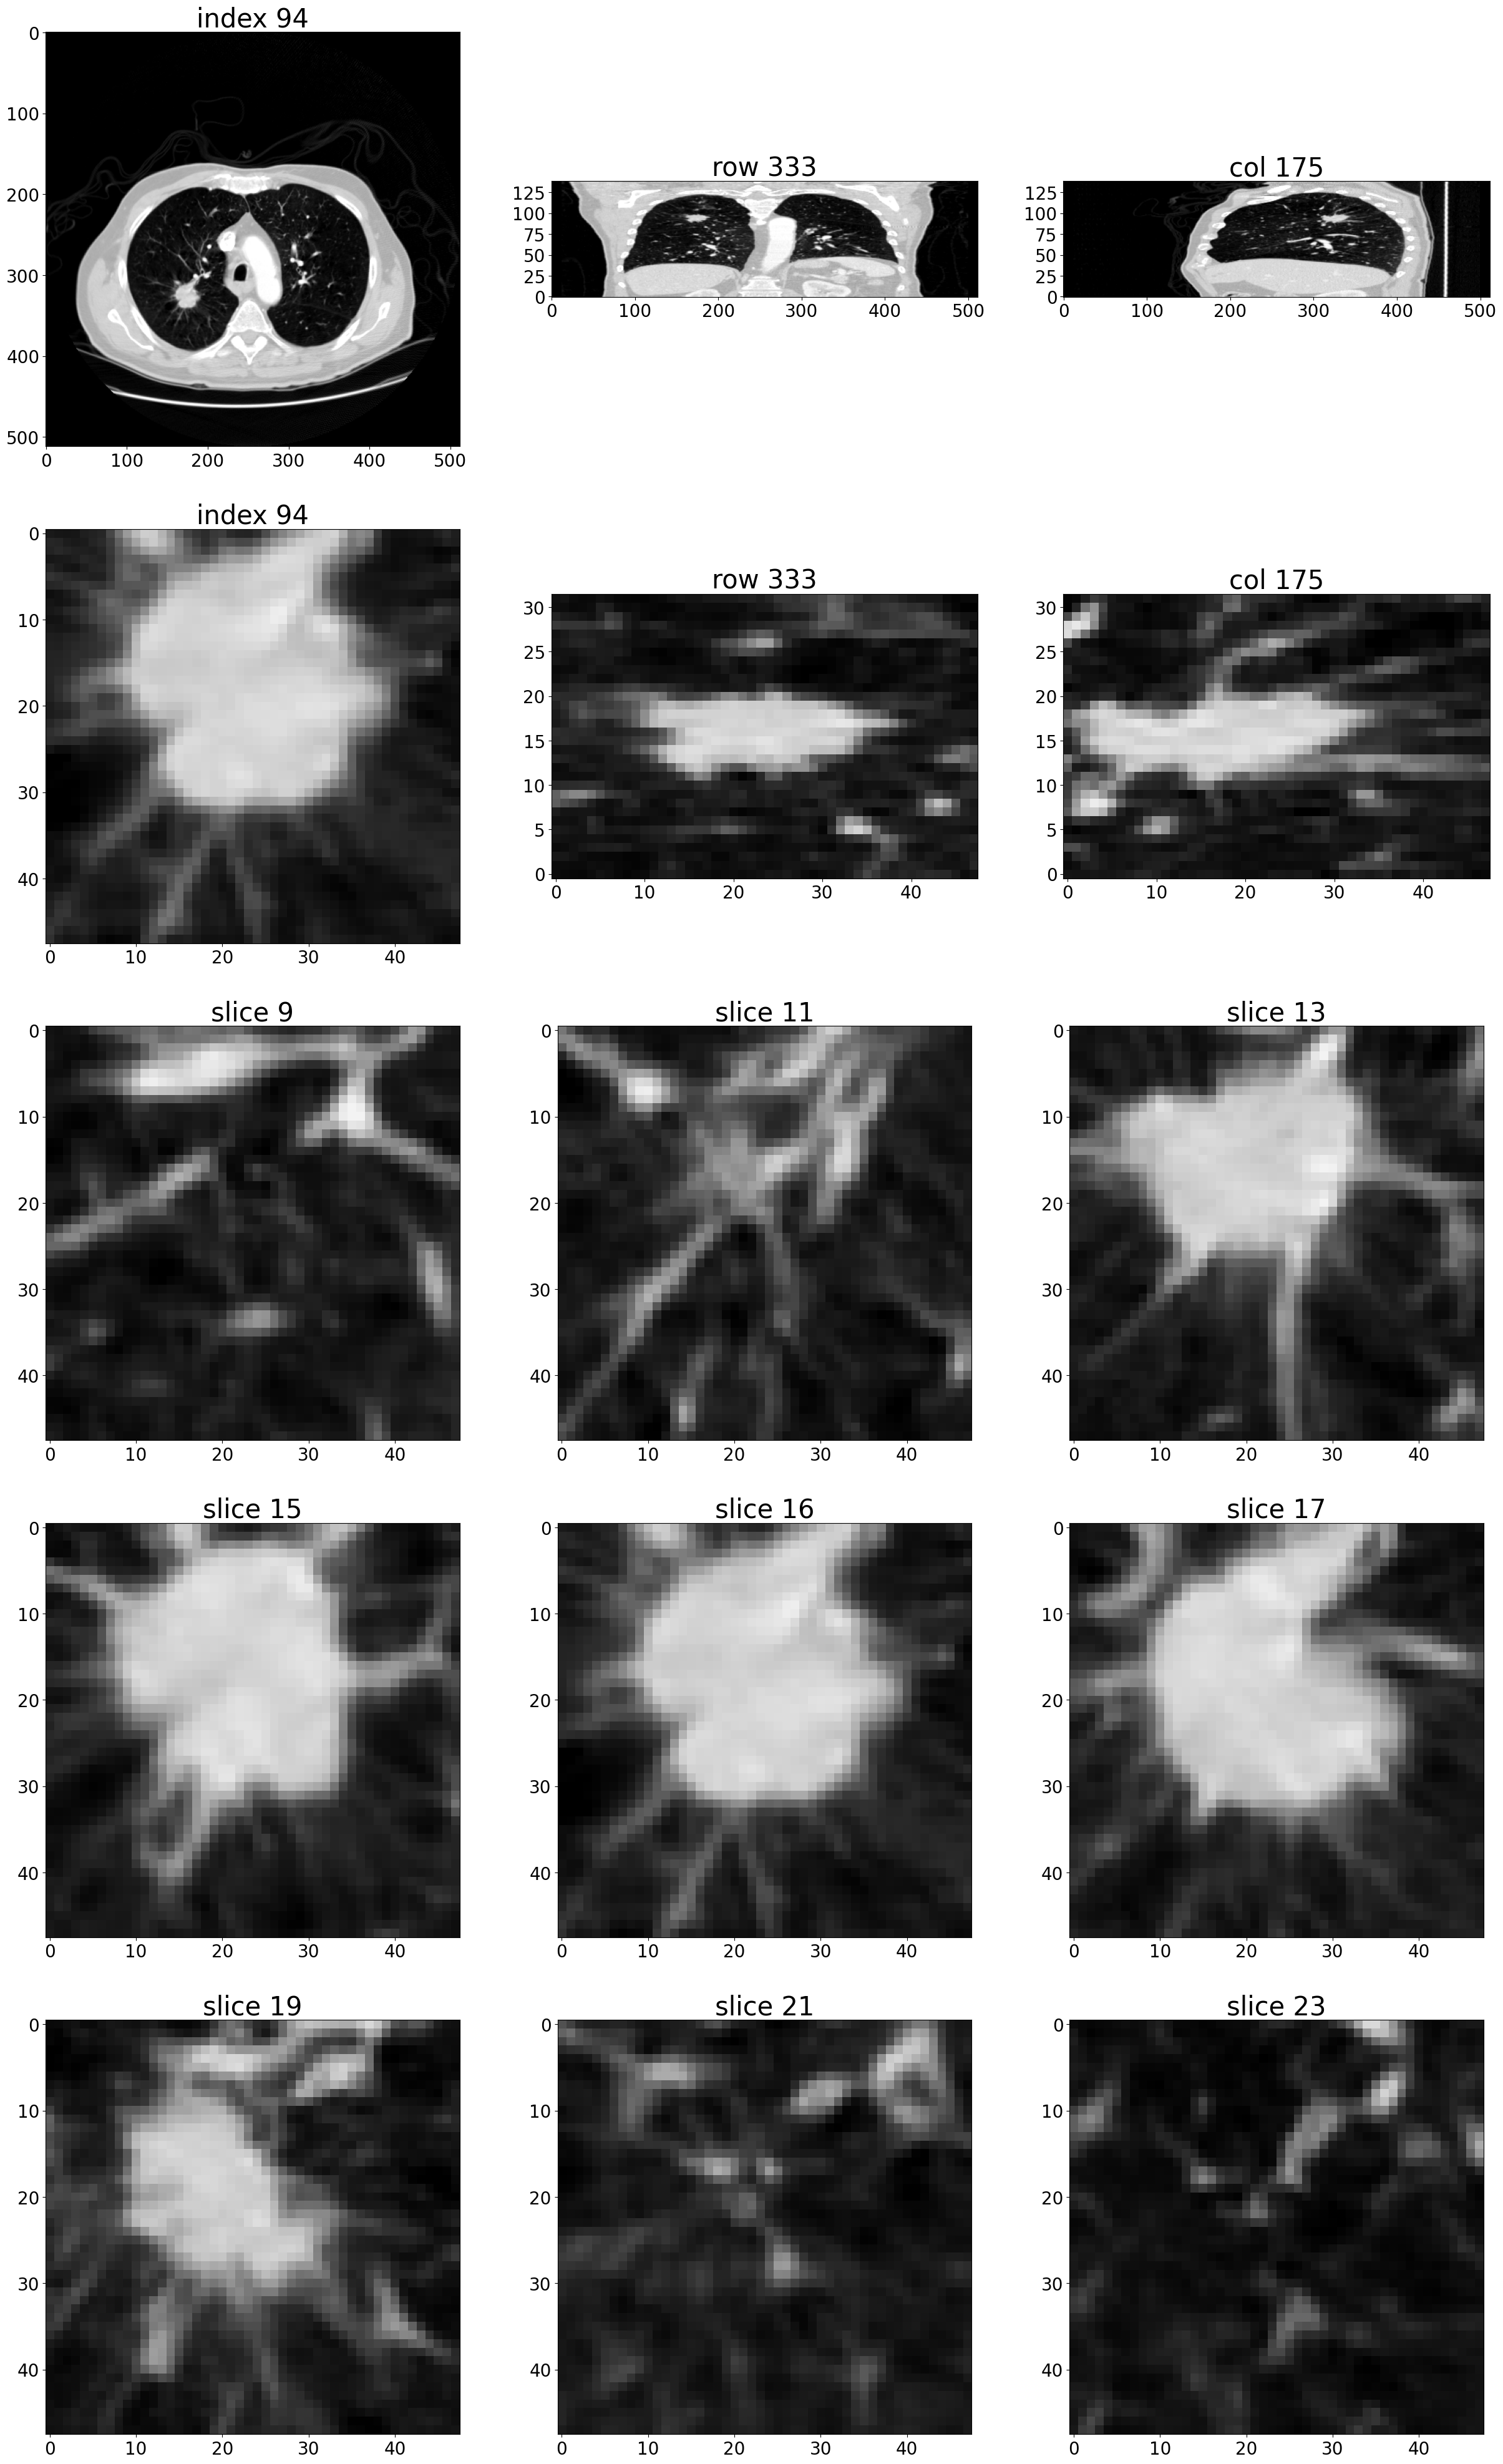

In [13]:
%matplotlib inline
series_uid = positiveSample_list[11][2]
showCandidate(series_uid)

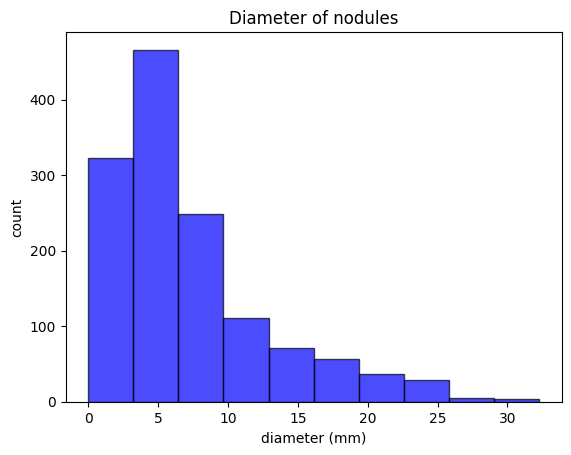

In [14]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.hist(diameter_list, bins=10, alpha=0.7, color='blue', edgecolor='black')
# Adding titles and labels
plt.title('Diameter of nodules')
plt.xlabel('diameter (mm)')
plt.ylabel('count')
# Show the plot
plt.show()

2026-03-10 17:32:00,672 INFO     pid:14888 functions.preprocess:165:__init__ <functions.preprocess.LunaDataset object at 0x0000020BA9A16330>: 543 training samples


1.3.6.1.4.1.14519.5.2.1.6279.6001.146987333806092287055399155268 0 False [0, 1, 2, 3, 4, 5, 6, 7, 8]


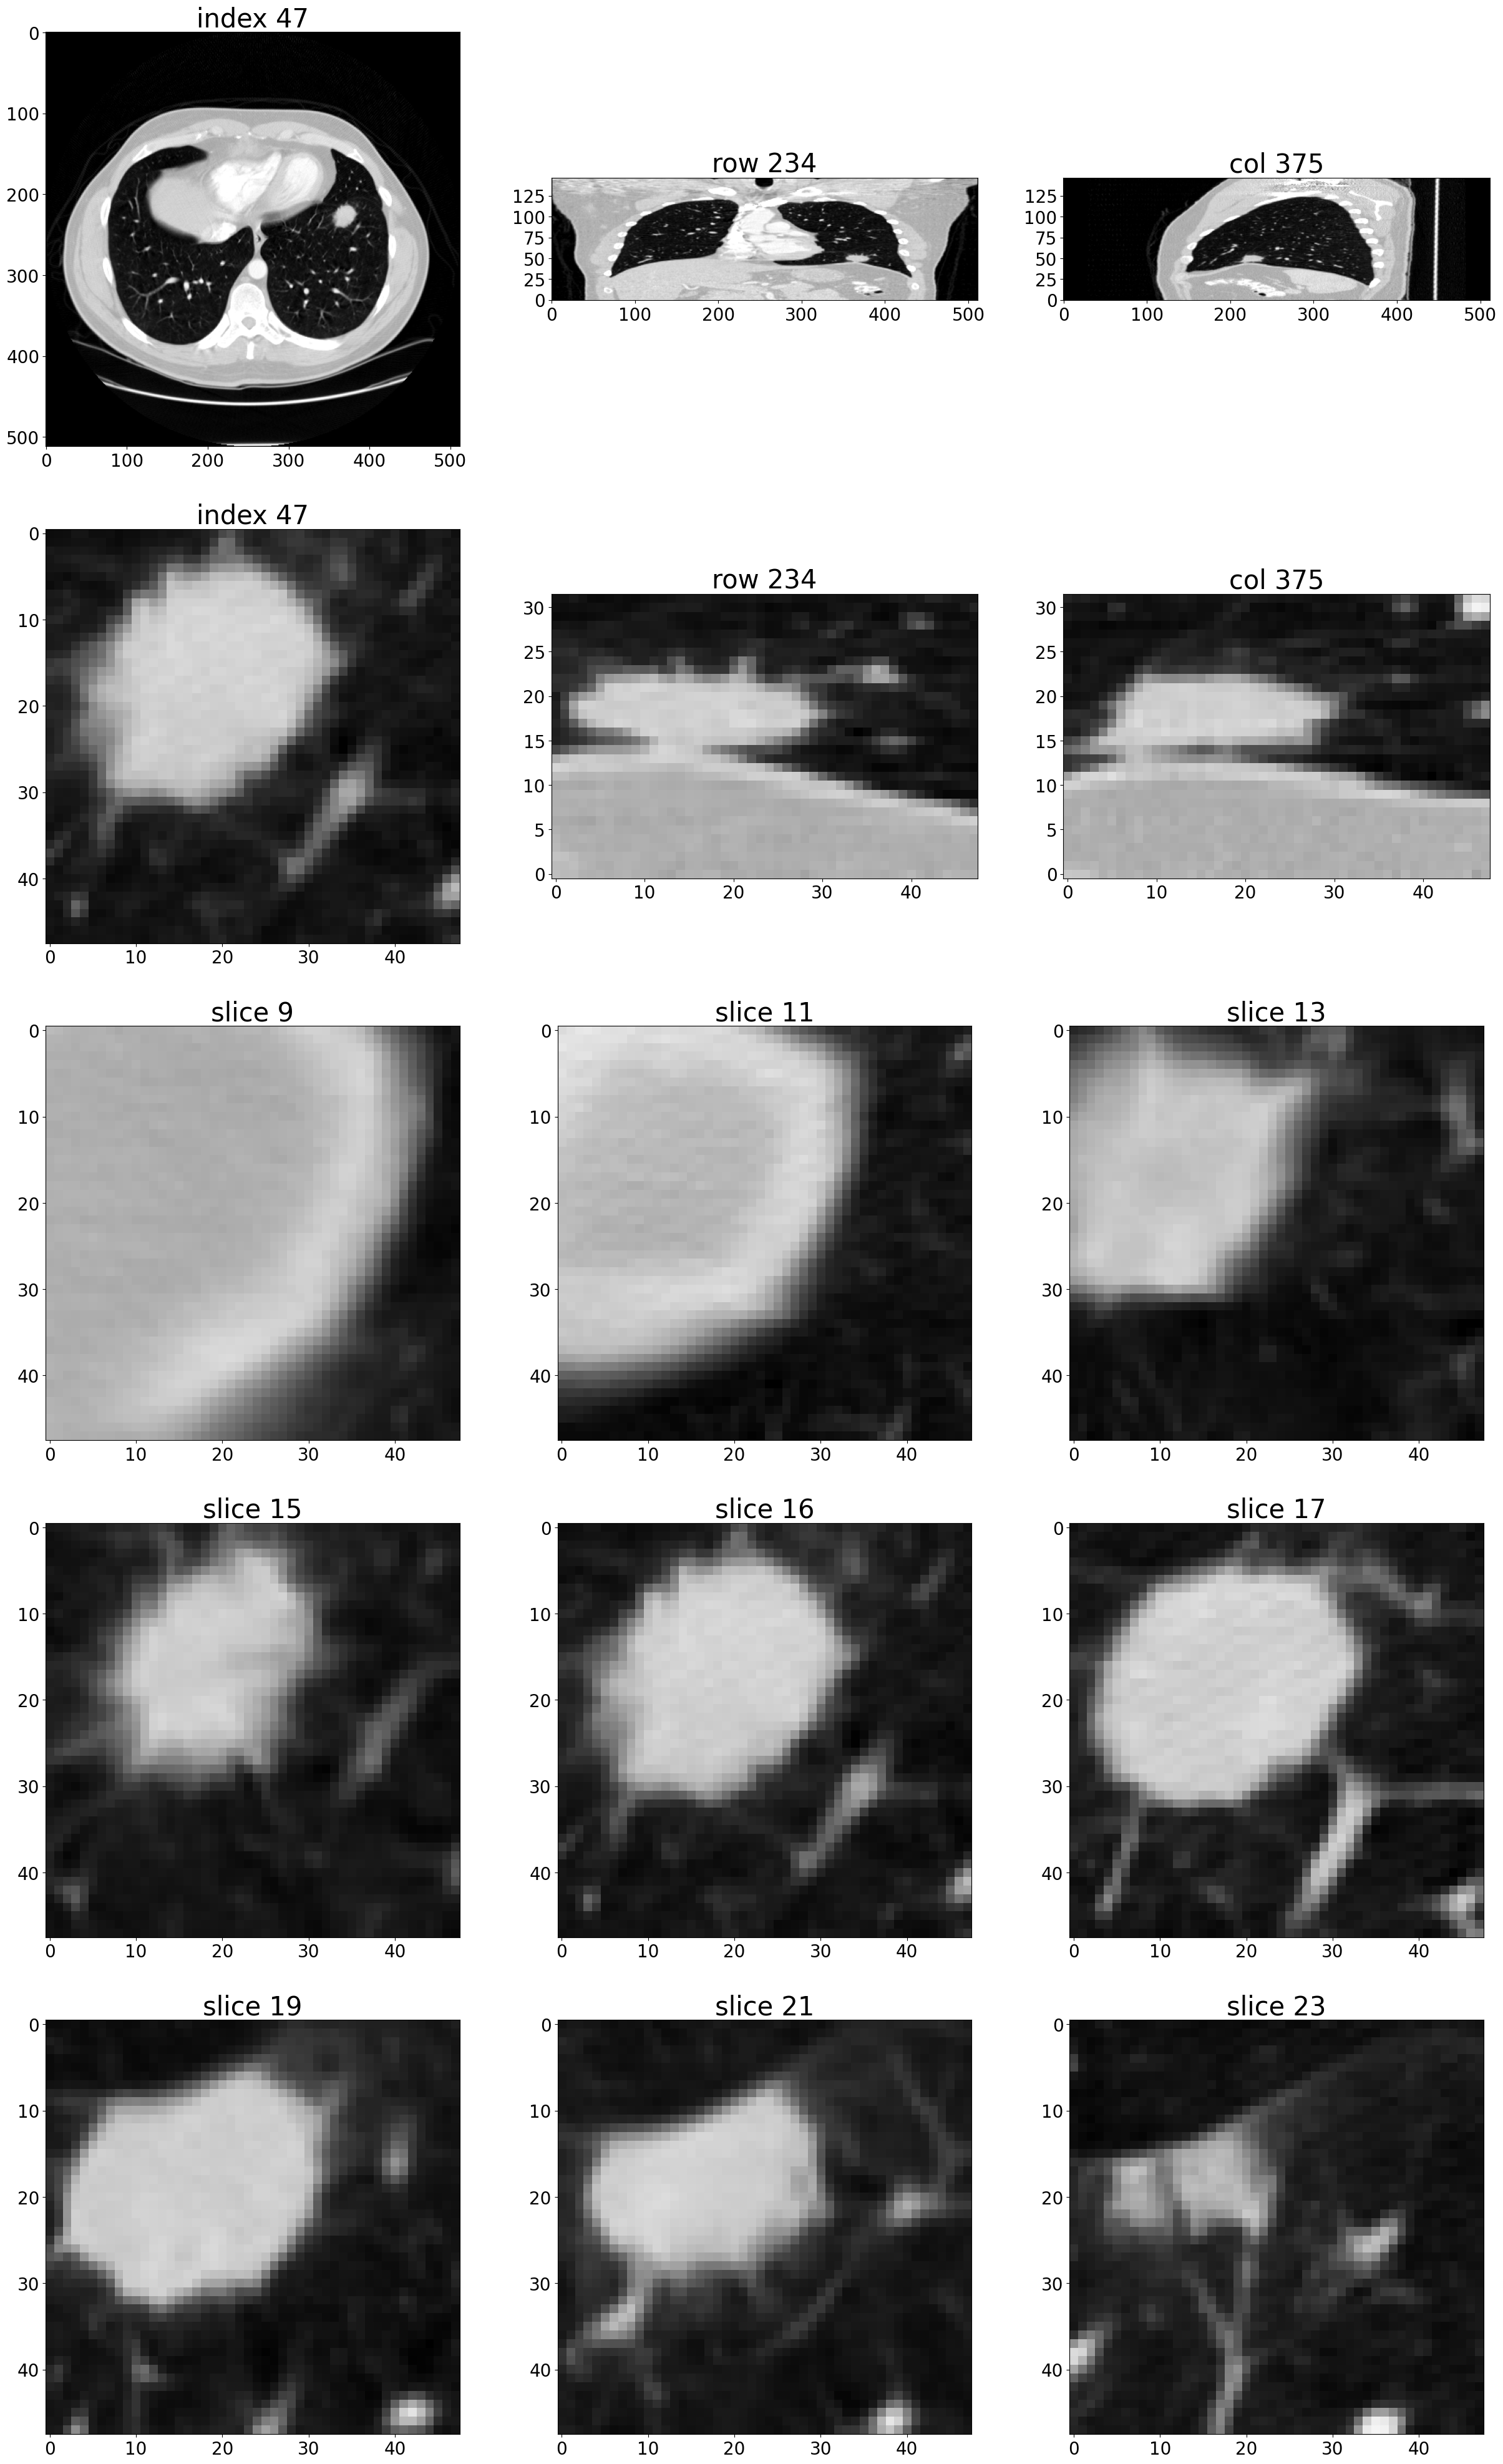

In [17]:
%matplotlib inline
series_uid = positiveSample_list[15][2]
showCandidate(series_uid)

이러한 코드로 앞에서 봤떤 CT나 결절 단면과 동일한 이미지를 볼 수 있다.

데이터 렌더링이 단지 멋진 그림을 보기 위한 용도는 아니다. 이를 통해 입력이 어떤 형상인지에 대한 직관을 키우기 위함이다. 문제를 추적하고 조사할 때 이미지를 보고 "이 데이터는 나머지에 비해 노이즈가 상당하군." 혹은 "이상하네. 데이터는 지극히 정상인데." 라고 말할 수 있다면 좋을 것이다.

혹은 "아마도 이 부분을 이렇게 바꿔주면 문제가 해결될 거야" 라고 말할 수 있는 직관력을 키워줄 수도 있다. 점점 더 어려운 프로젝트에 도전할수록 익숙해질 필요가 있다.

## 10.6 결론

10장에서는 파이토치가 우리 데이터에 대해 감을 잡도록 만들었다. DICOM 메타 이미지 원본 데이터를 텐서로 변환했고 이제 다음 11장에서 모델을 구현하고 훈련 루프를 시작할 준비를 모두 마쳤다.

여기까지 진행하며 내렸던 많은 결정사항은 매우 중요하다. 입력 크기, 캐싱 구조, 그리고 훈련셋과 검증셋을 어떻게 파티션 했는지 등은 프로젝트 전체의 성공 여부에 크게 영향을 미친다.

## 10.7 연습문제

## 10.8 핵심 요약

  - 원본 데이터를 파싱하고 읽는 코드는 중요하다. 이번 프로젝트에서 우리는 디스크에서 데이터를 로딩하고 관심 부분을 중심으로 크롭한 데이터에 접근할 수 있게 하는 `Ct` 클래스를 구현했다.
  - 파싱과 로딩 루틴의 비용이 클수록 캐싱은 유용하다. 어떤 캐싱은 메모리에서 동작하지만, 디스크에서 최적으로 동작하는 경우도 있다. 데이터 로딩을 위한 파이프라인에 각각이 필요한 지점이 존재한다.
  - 파이토치 `Dataset` 서브클래스는 데이터를 원본 형태에서 모델에 전달하기 적합한 텐서 형태로 변환할 때 사용하며, 실세계의 데이터를 파이토치 API로 통합할 때 필요한 기능이다.
  - `Dataset` 서브클래스는 `__len__`과 `__getitem__` 의 두 가지 메소드를 구현해줘야 한다. 추가 헬퍼(helper)메소드를 만들어도 되지만 필수는 아니다.
  - 데이터를 훈련셋과 검증셋으로 구분할 때에는 같은 샘플이 두 군데 다 있지 않도록 주의해야 한다. 여기에서는 두 세트를 구분할 때 항상 고정된 데이터 정렬 순서를 사용했고 매 10번째 샘플을 모아 검증셋으로 만들었다.
  - 데이터 시각화는 중요하다. 데이터를 시각화해서 보게 되면 에러나 문제에 대한 중요한 단서를 파악할 수 있다. 데이터 렌더링을 위해 우리는 주피터 노트북과 맷플롯립을 사용했다.
